<a href="https://colab.research.google.com/github/nitrogenlab/pyompa/blob/main/examples/Tutorial_On_End_Member_Usage_Penalties_in_PYOMPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

When the number of unknowns (end-members + remineralization ratio) exceeds the number of parameters capable of providing constraints, the optimal solution is undetermined i.e. ambiguous. One way to reduce this ambiguity is that if you have prior knowledge on where certain end-members are likely to be located, you can impose penalties for solutions that contain the end-member outside of the regions where the end-member is permitted. This notebook guides the user on how to configure such penalties in PYOMPA.

**Note that this approach is not guaranteed to completely remove ambiguity from the solution**. For example, if the ambiguity exists in regions where no usage penalty is imposed on the end-members, the solution will remain under-determined. PYOMPA can be used to quantify the ambiguity in the solution, in case this is a concern.

We will begin by creating an example of an underdetermined system and will show how end-member usage penalties can be imposed to shape the PYOMPA solution

# Download the data and install pyompa

Install pyompa

In [1]:
!pip install pyompa

Prepare the dataset (this is a dataset provided by Natalya Evans)

In [2]:
#Download the data
!wget https://raw.githubusercontent.com/nitrogenlab/pyompa/cee3123/examples/FK_ompa_04s.mat -O FK_ompa_04s.mat

--2026-01-03 06:13:11--  https://raw.githubusercontent.com/nitrogenlab/pyompa/cee3123/examples/FK_ompa_04s.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38252 (37K) [application/octet-stream]
Saving to: ‘FK_ompa_04s.mat’

FK_ompa_04s.mat     100%[===================>]  37.36K  --.-KB/s    in 0.01s   

2026-01-03 06:13:12 (3.08 MB/s) - ‘FK_ompa_04s.mat’ saved [38252/38252]



In [3]:
import scipy.io
from scipy.io import loadmat
import pandas as pd
import numpy as np

inp_data = loadmat("FK_ompa_04s.mat")

#Prepare a data frame for the data
falkor_df = pd.DataFrame({
    'lat': inp_data['lat'].flatten(),
    'long': inp_data['long'].flatten(),
    'pdens': inp_data['pdens'].flatten(),
    'conservative_temp': inp_data['ptemp'].flatten(),
    'absolute_salinity': inp_data['sal'].flatten(),
})

#Filter the data frame to density ranges used for intermediate waters
intermediatewaters_falkordf = pd.DataFrame(
    falkor_df[(falkor_df["pdens"] >= 26.0)
              & (falkor_df["pdens"] <= 27.0)])

#Define the end-members
#                                   temp       sal
CW13_FK =        ["13CW_FK",       12.54,    34.98]
NEPIW_FK =       ["NEPIW_FK",       9.56,    34.80]
AAIW =           ["AAIW",           6.03,    34.70]

def prepare_endmember_df(endmembers_arr):
    df = pd.DataFrame(data=endmembers_arr,
                      columns=["endmember_name", "conservative_temp", "absolute_salinity"])
    return df

intermediatewaters_FK_endmemberdf = prepare_endmember_df(
    [CW13_FK, NEPIW_FK, AAIW])

## Solution without end-member usage penalties

To demonstrate an ambiguous solution, we will first solve for the 3 end-members with just two constraints: temperature and mass conservation (salinity is also available and would disambiguate the solution, but we do this for illustration purposes only)

In [4]:
import pyompa

evansorig_paramweightings = {
    "conservative_temp": 24.0,
    #"absolute_salinity": 24.0,
}

evansorig_settings = {
    "param_names": ["conservative_temp"],# "absolute_salinity"],
    "param_weightings": evansorig_paramweightings,
    "convertedparam_groups": [],
    "sumtooneconstraint": True
}

#Run the analysis
orig_intermediate_falkordf_ompasoln = pyompa.OMPAProblem(
  obs_df = intermediatewaters_falkordf,
  **evansorig_settings).solve(
      intermediatewaters_FK_endmemberdf,
      endmember_name_column="endmember_name")

Endmember-idx mapping is
 OrderedDict({'13CW': [0], 'NEPIW': [1], 'AAIW': [2]})
params to use: ['conservative_temp']
param weighting: [24.]
Matrix A:
On example 0 to 279 out of 279
status: optimal
optimal value 20221.69397773142
Original weighted sum squares: 20221.69397773142
Post fix weighted sum squared: 20221.943616000055
objective: 20221.943616000055


Display the results

Water mass fractions


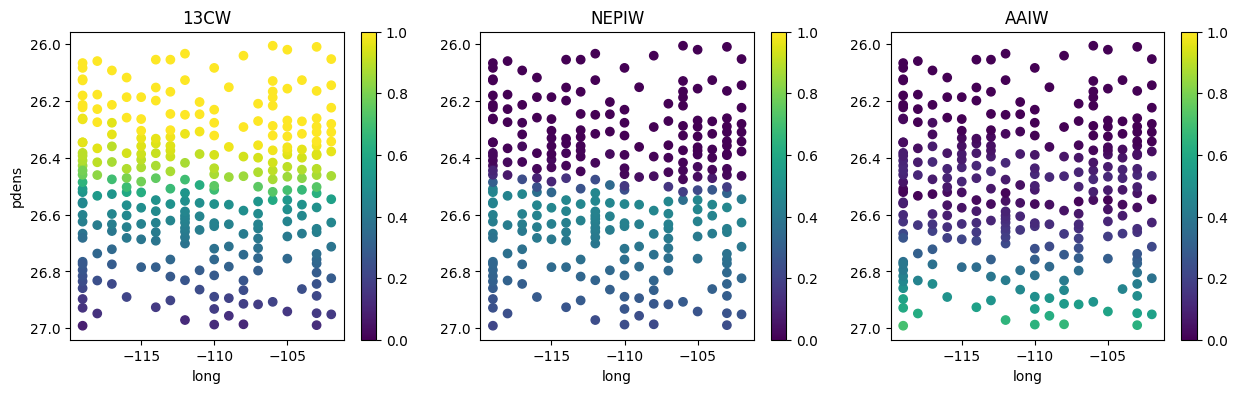

Residuals


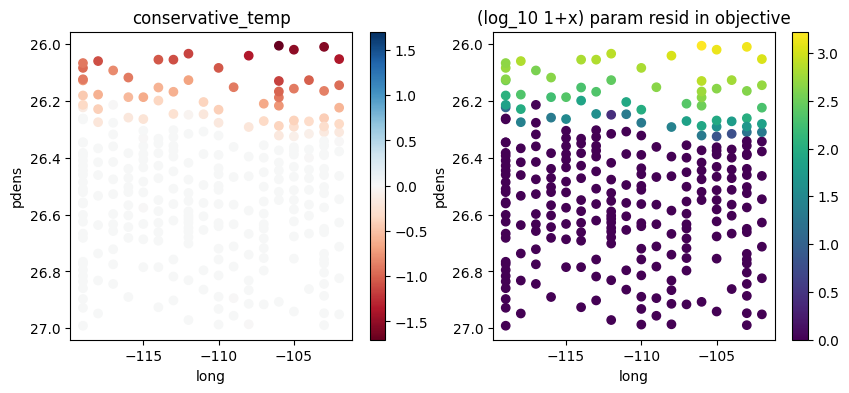

In [5]:
from matplotlib import pyplot as plt
from pyompa import (plot_ompasoln_endmember_fractions,
                    plot_ompasoln_residuals,
                    plot_ompasoln_endmember_usagepenalties)

yaxis_colname = "pdens"
print("Water mass fractions")
plot_ompasoln_endmember_fractions(ompa_soln=orig_intermediate_falkordf_ompasoln,
                                  xaxis_colname="long",
                                  yaxis_colname=yaxis_colname)
print("Residuals")
plot_ompasoln_residuals(ompa_soln=orig_intermediate_falkordf_ompasoln,
                        xaxis_colname="long",
                        yaxis_colname=yaxis_colname)

### Quantify the ambiguity in the solution

In order to quantify the ambiguity in the solution, we will configure an optimization problem that maximizes/minimizes the usage of a given end-member subject to the constraint that the residuals must be identical to the residuals in the previously-calculated solution

On 13CW


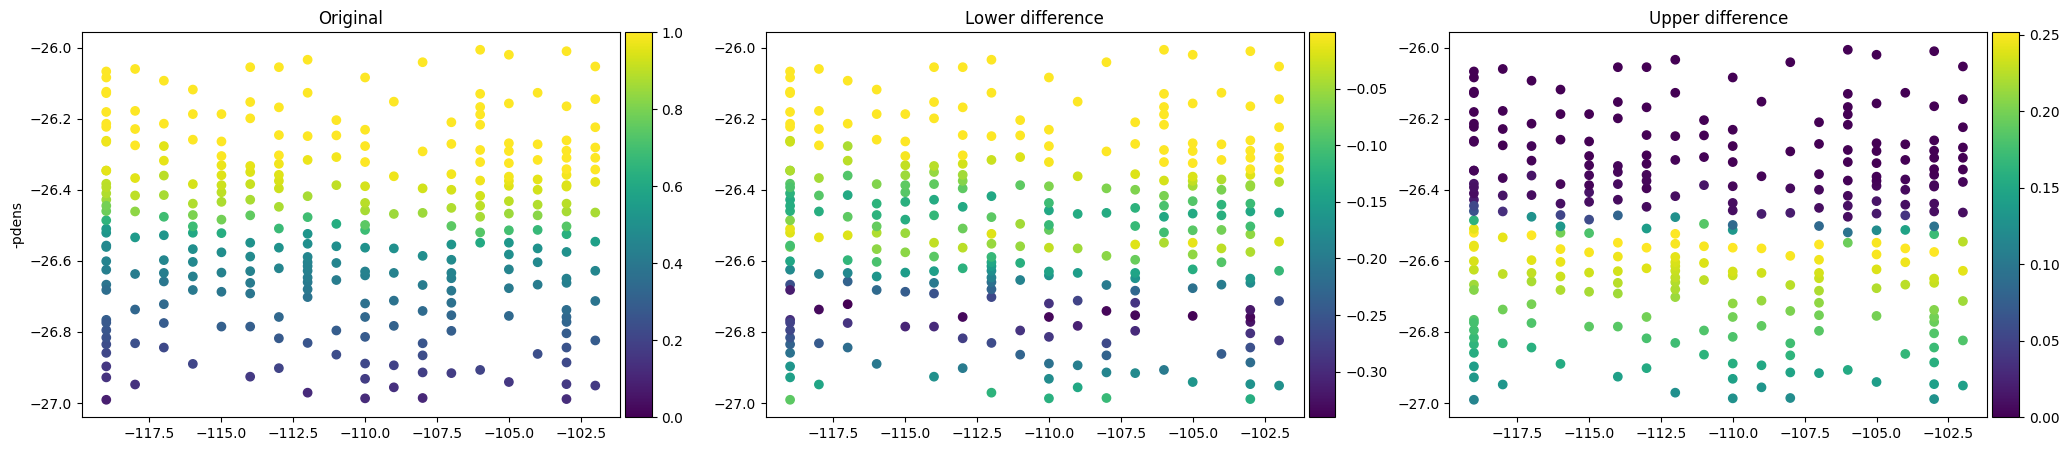

On NEPIW


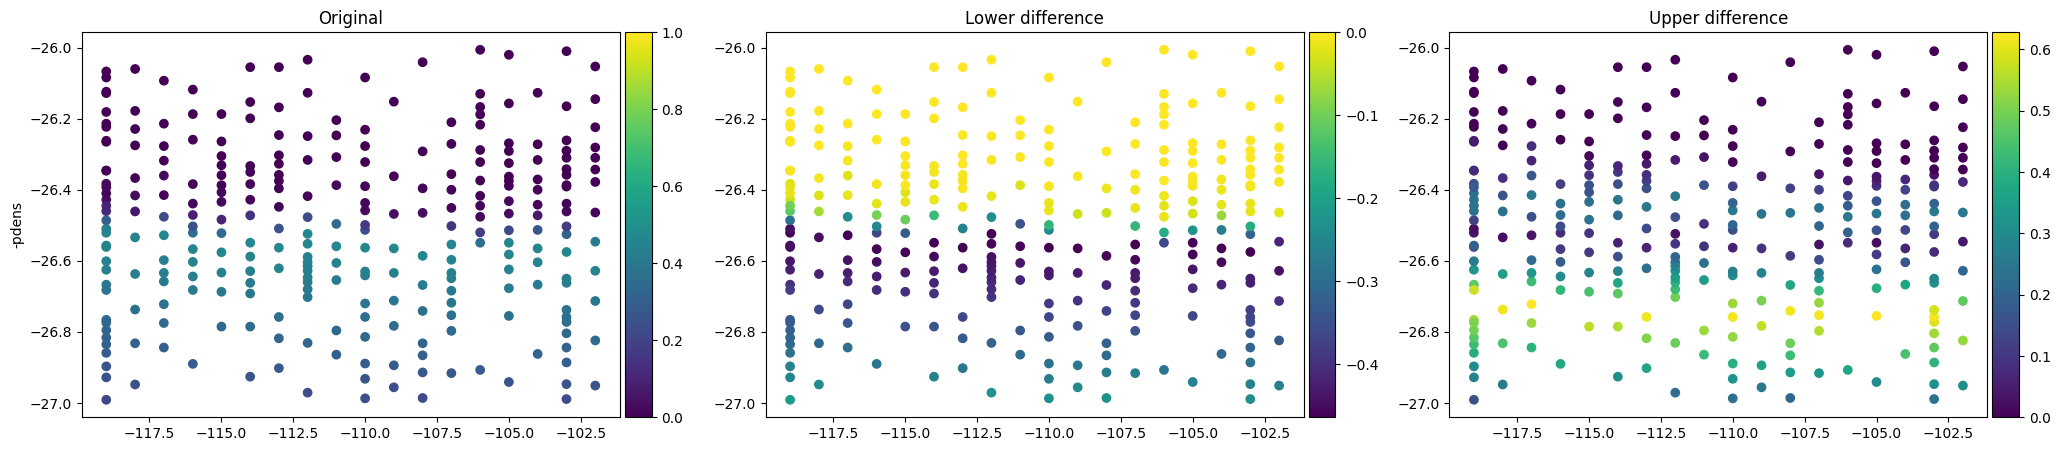

On AAIW


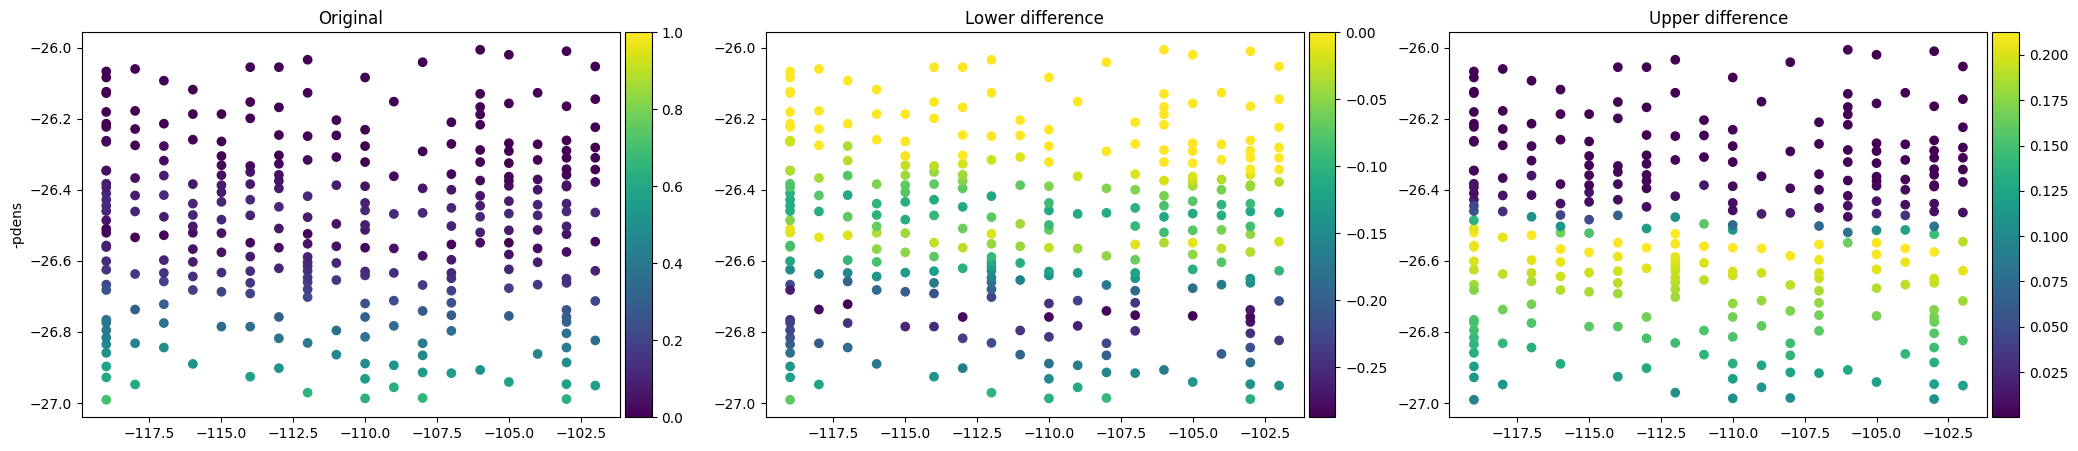

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_ambiguity_in_solution(soln, max_resids, xvar, yvar):
  #soln: the original OMPA solution
  #xvar: the variable to plot on the x axis
  #yvar: the variable to plot on the y axis

  ambiguity_results_max = {}
  ambiguity_results_min = {}

  #Iterate over all the end members
  for endmemberoverallidx, (endmembername, endmember_idxs) in enumerate(soln.endmembername_to_indices.items()):
      print("On",endmembername)
      #Configure an objective that says 'maximize the amount of a particular end-member'
      #maximizing_obj is a vector that says what the value of the objective is going to be as a function
      # of the values of the unknowns that are solved for. The length of maximizing_obj is equal to the
      # number of unknowns that are solved for.
      #To maximize the value of a particular end-member, we will set the maximizing_obj to 0 for all the
      # other unknowns and -1 for the unknown corresponding to the index of that end-member. We set it to
      # -1 rather than 1 as a lower value of the objective is what is solved for.
      maximizing_obj = np.zeros((len(soln.endmember_names) + soln.ompa_problem.num_converted_variables,))
      maximizing_obj[endmember_idxs] = -1 #-1 is a maximizing objective because lower is better

      ompasoln_max = pyompa.ompacore.OMPASoln.core_quantify_ambiguity_via_residual_limits(
                                    self=soln, obj_weights=maximizing_obj,
                                    max_resids=max_resids)
      ambiguity_results_max[endmembername] = ompasoln_max

      #Now configure an objective that says 'minimize the amount of a particular end-member'
      minimizing_obj = np.zeros((len(soln.endmember_names) + soln.ompa_problem.num_converted_variables,))
      minimizing_obj[endmember_idxs] = 1
      ompasoln_min = pyompa.ompacore.OMPASoln.core_quantify_ambiguity_via_residual_limits(
                                    self=soln, obj_weights=minimizing_obj, max_resids=max_resids)
      ambiguity_results_min[endmembername] = ompasoln_min

      ###
      #Plot the results
      # 'Lower difference' and 'Upper difference' are the difference between the
      # minimizing/maximizing solution and the original solution, respectively
      #Since the lower difference and upper difference can be quite large as indicated
      # by the scale of the colorbar, we know that there is considerable ambiguity in
      # the solution
      ###
      fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(25,5))
      #Make the scatterplot with longitude and potential density
      origscatter = ax[0].scatter(soln.obs_df[xvar], -soln.obs_df[yvar],
                                  c=np.sum(soln.endmember_fractions[:,endmember_idxs], axis=1),
                                  vmin=0, vmax=1.0)
      divider = make_axes_locatable(ax[0])
      cax = divider.append_axes('right', size='5%', pad=0.05)
      plt.colorbar(origscatter, cax=cax)
      ax[0].set_title("Original")
      ax[0].set_ylabel("-"+yvar)

      lowerscatter = ax[1].scatter(soln.obs_df[xvar], -soln.obs_df[yvar],
                      c=np.sum(ompasoln_min.endmember_fractions[:,endmember_idxs], axis=1) - np.sum(soln.endmember_fractions[:,endmember_idxs], axis=1),
                      )
      divider = make_axes_locatable(ax[1])
      cax = divider.append_axes('right', size='5%', pad=0.05)
      plt.colorbar(lowerscatter, cax=cax)
      ax[1].set_title("Lower difference")

      upperscatter = ax[2].scatter(soln.obs_df[xvar], -soln.obs_df[yvar],
                              c=np.sum(ompasoln_max.endmember_fractions[:,endmember_idxs], axis=1) - np.sum(soln.endmember_fractions[:,endmember_idxs], axis=1),
                              )
      divider = make_axes_locatable(ax[2])
      cax = divider.append_axes('right', size='5%', pad=0.05)
      plt.colorbar(upperscatter, cax=cax)
      ax[2].set_title("Upper difference")

      plt.show()

#max_resids stores the maximum increase in the residual allowed for each parameter
# we set it to a vector of zeros (one for each parameter) to ensure we explore
# solutions that are no worse than the optimal solution previously identified
max_resids = np.array([0.0]) #a vector with only one zero as we solved for just one parameter (temperature)
plot_ambiguity_in_solution(soln=orig_intermediate_falkordf_ompasoln, #this is the solution previously identified
                           max_resids=max_resids,
                           xvar="long",
                           yvar="pdens")



# Solve with end-member usage penalties

We will now introduce penalties on where particular end-members can appear in the solution.

To specify the penalty function, we have to define a function that says how the penalty will change based on the sample features. The input to the penalty function is a data frame of the sample features, and the output is the penalty for each row of the data frame. An example is provided below:

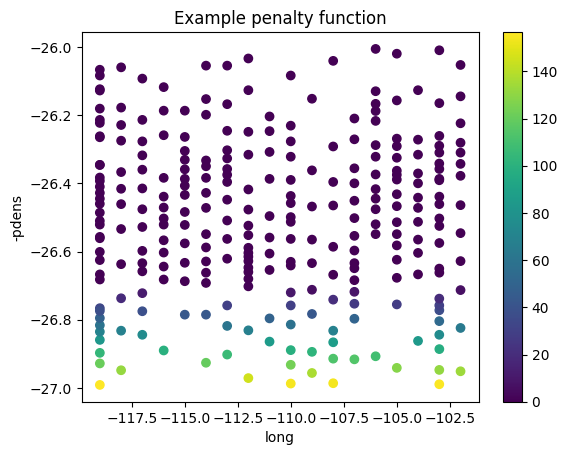

In [7]:
def example_penalty_func(df):
  pdens_values = df["pdens"]
  alpha = 0.5
  beta = 1000
  penalty = beta*(np.exp(alpha*np.maximum(0, pdens_values-26.7))-1)
  return penalty

def plot_penalty_function(df, penalty_func, title):
    penalties = penalty_func(df)
    plt.scatter(df["long"], -df["pdens"], c=penalties)
    plt.colorbar()
    plt.xlabel("long")
    plt.ylabel("-pdens")
    plt.title(title)
    plt.show()

#You can visualize the penalties by calling the penalty function on the
# samples data frame
plot_penalty_function(df=intermediatewaters_falkordf,
                      penalty_func=example_penalty_func,
                      title="Example penalty function")

#Pyompa has helper functions that make it easy to define penalty functions.
# For example, the example penalty function is equivalent
# to the following penalty defined using 'GeneralPenaltyFunc'
from pyompa import GeneralPenaltyFunc
equivalent_example_penalty = GeneralPenaltyFunc(
        spec={'pdens':{'type':'exp_density_default', 'upperbound':26.7}})
assert np.allclose(equivalent_example_penalty(intermediatewaters_falkordf),
                   example_penalty_func(intermediatewaters_falkordf))

We will now define the penalty functions for the three different water types

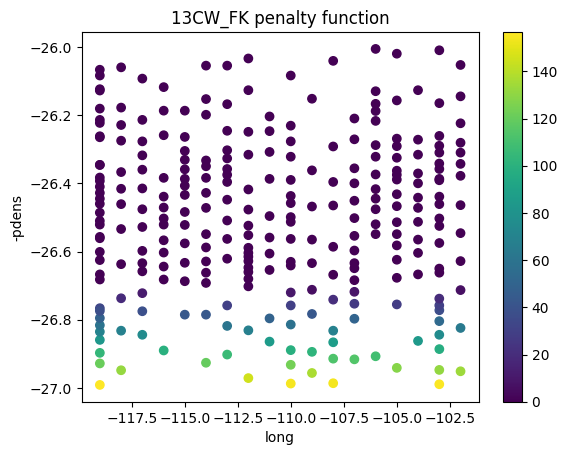

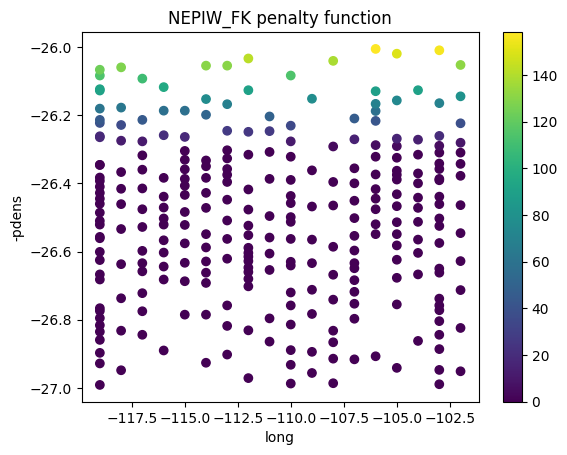

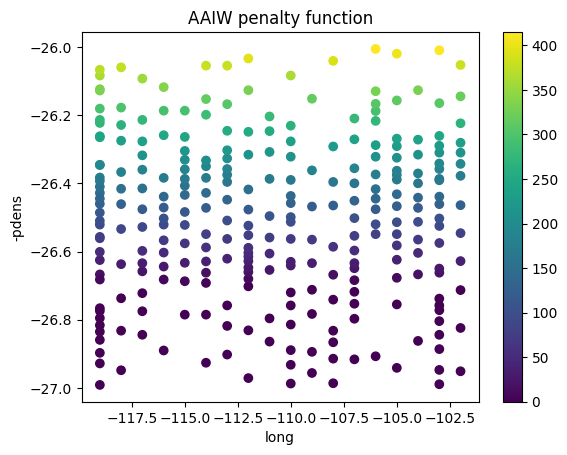

In [8]:
from pyompa import GeneralPenaltyFunc

endmembername_to_usagepenaltyfunc = {
    "13CW_FK": GeneralPenaltyFunc(
        spec={'pdens':{'type':'exp_density_default', 'upperbound':26.7}}),
    "NEPIW_FK": GeneralPenaltyFunc(
        spec={'pdens':{'type':'exp_density_default', 'lowerbound':26.3}}),
    "AAIW": GeneralPenaltyFunc(
        spec={'pdens':{'type':'exp_density_default', 'lowerbound':26.7}})
}

#Visualize them
for endmember, penalty_func in endmembername_to_usagepenaltyfunc.items():
  plot_penalty_function(df=intermediatewaters_falkordf,
                        penalty_func=penalty_func,
                        title=f"{endmember} penalty function")


Now we will compute the pyompa solution using these penalty functions

Adding penalty for 13CW_FK
Adding penalty for NEPIW_FK
Adding penalty for AAIW
Endmember-idx mapping is
 OrderedDict({'13CW': [0], 'NEPIW': [1], 'AAIW': [2]})
params to use: ['conservative_temp']
param weighting: [24.]
Matrix A:
On example 0 to 279 out of 279
status: optimal
optimal value 20227.712271461172
Original weighted sum squares: 20222.157412052446
Post fix weighted sum squared: 20222.15741238853
objective: 20222.15741238853
Water mass fractions


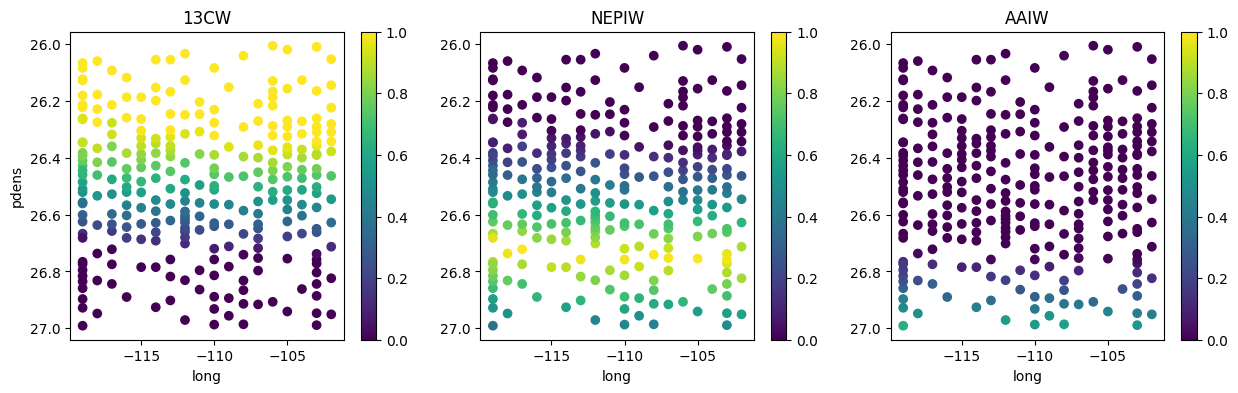

Residuals


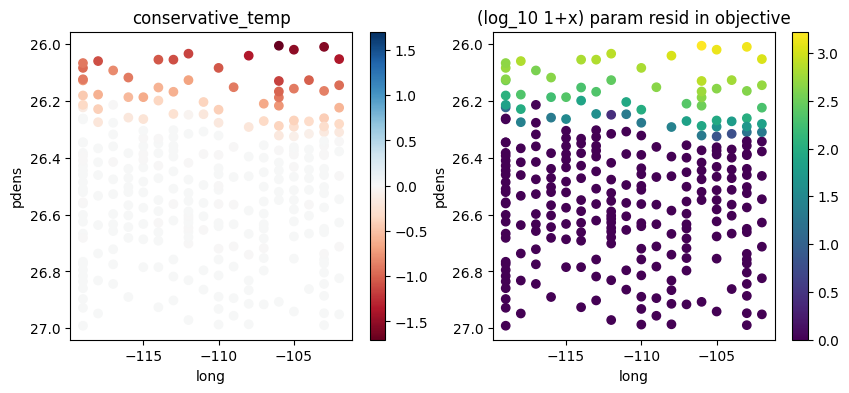

In [9]:
#Run the analysis
withusagepenalties_intermediate_falkordf_ompasoln = pyompa.OMPAProblem(
  obs_df = intermediatewaters_falkordf,
  endmembername_to_usagepenaltyfunc=endmembername_to_usagepenaltyfunc,
  **evansorig_settings).solve(
      intermediatewaters_FK_endmemberdf,
      endmember_name_column="endmember_name")

print("Water mass fractions")
plot_ompasoln_endmember_fractions(ompa_soln=withusagepenalties_intermediate_falkordf_ompasoln,
                                  xaxis_colname="long",
                                  yaxis_colname="pdens")
print("Residuals")
plot_ompasoln_residuals(ompa_soln=withusagepenalties_intermediate_falkordf_ompasoln,
                        xaxis_colname="long",
                        yaxis_colname="pdens")

Let us also visualize the ambiguity in this new solution; from the scale of the y-axis in the "Lower difference" and "Upper difference" panels, we see that the ambiguity is greatly decreased

On 13CW


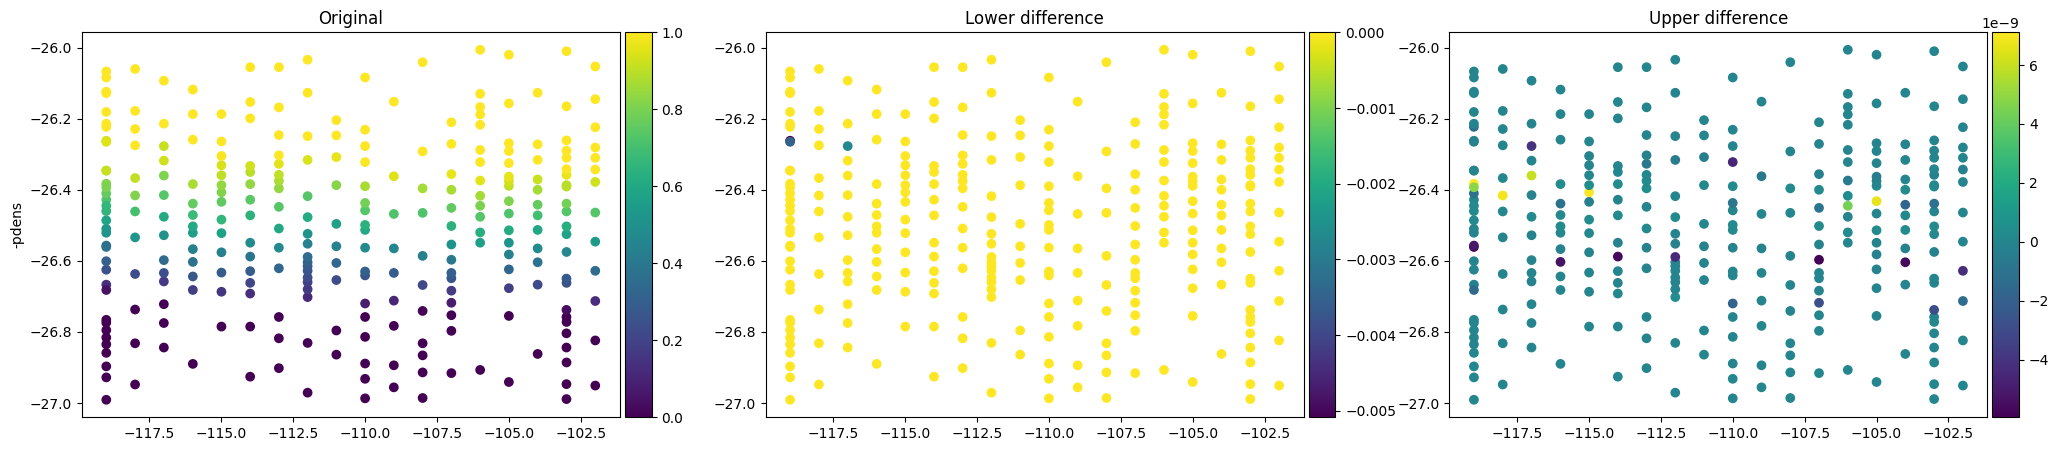

On NEPIW


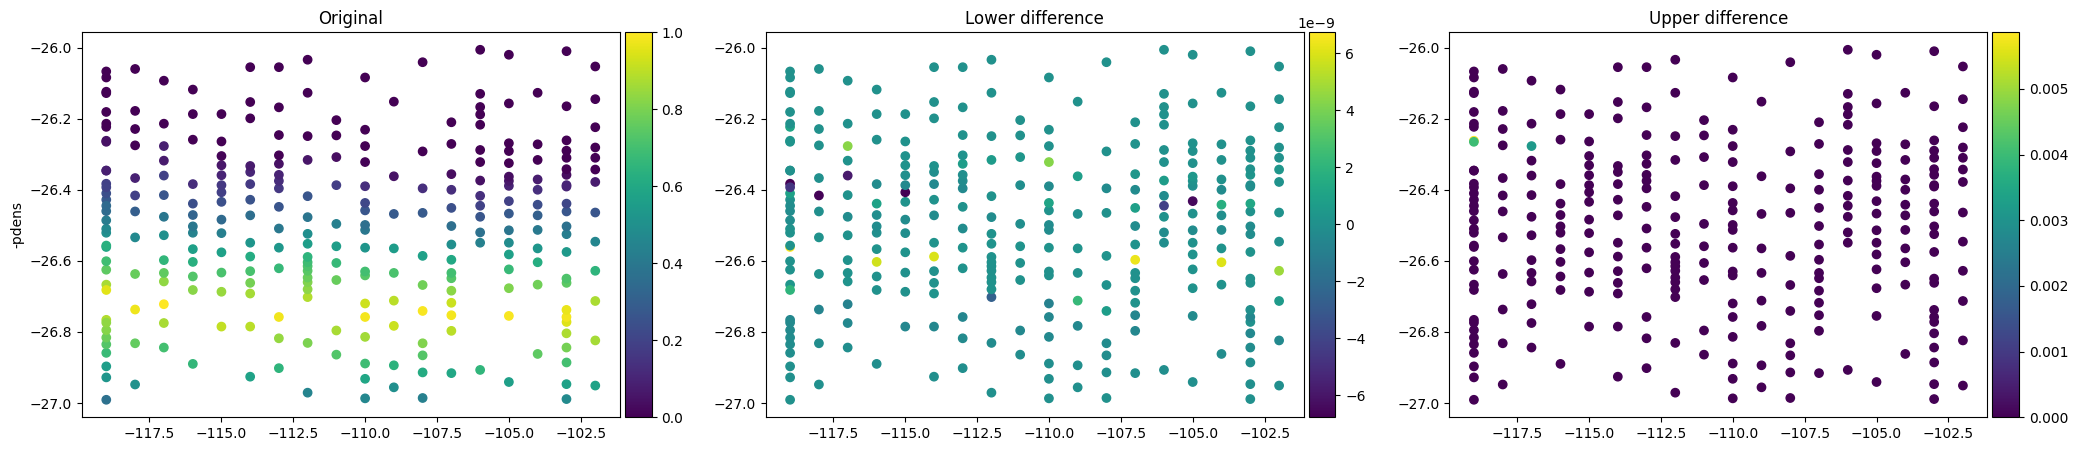

On AAIW


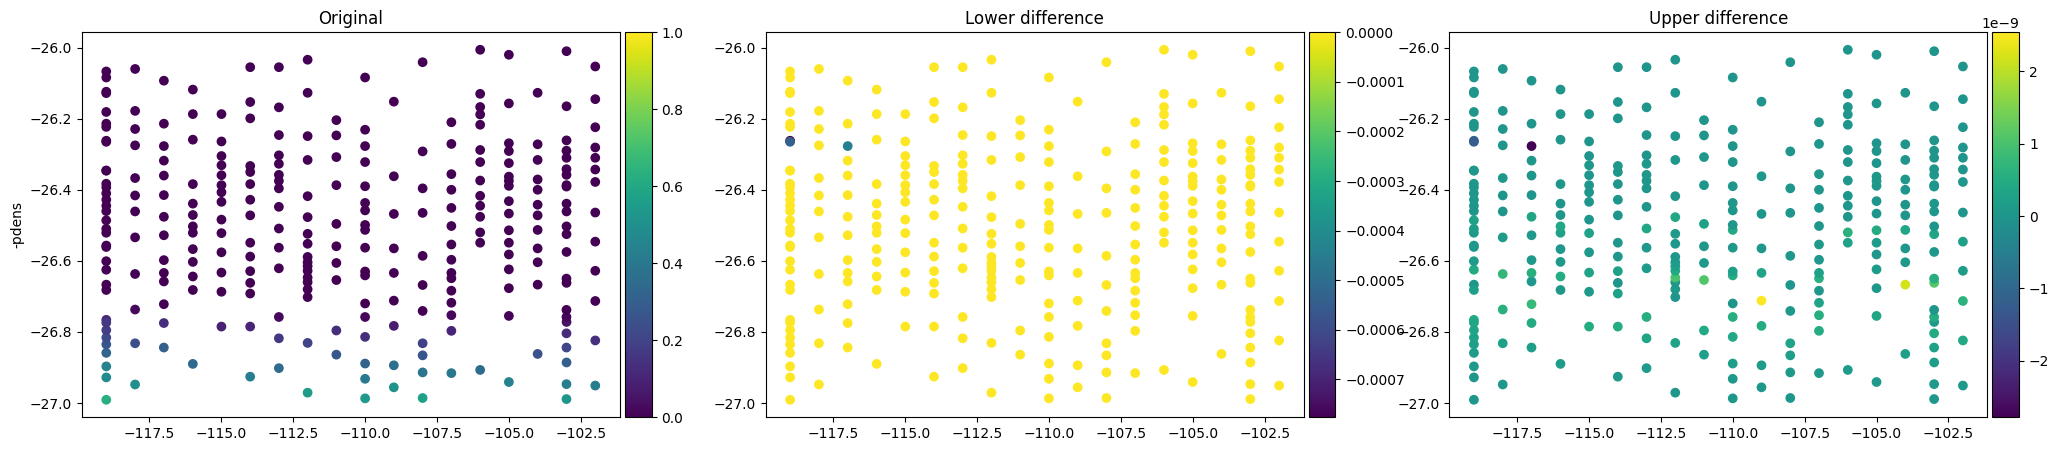

In [10]:
plot_ambiguity_in_solution(soln=withusagepenalties_intermediate_falkordf_ompasoln,
                           max_resids=max_resids,
                           xvar="long",
                           yvar="pdens")
